Importar libreria de pandas

In [1]:
import pandas as pd

Cargamos el archivo CSV

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Cargamos las primeras filas del dataset usando [df.head] sirve para mostrar las primeras 5 filas de un dataset

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/kevinnumanzor17/Kevin_Umanzor_2522192022/refs/heads/main/Dataset/clave_I_correlacion.csv")
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,I-C0001,18,1208,8,70.27,6.38,4,5,33.92,442.88
1,I-C0002,38,1221,7,77.75,7.44,2,6,22.83,543.68
2,I-C0003,45,1385,8,84.56,6.56,3,6,29.00,641.28
3,I-C0004,48,1044,4,71.45,4.79,4,4,29.42,262.21
4,I-C0005,31,808,5,51.72,7.92,1,4,19.00,321.18


Indentificamos las variables numericas

In [4]:
print(df.select_dtypes(include=['int64', 'float64']).columns)

Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')


-- ahora revisamos datos nulos, valores atípicos y consistencia general.

datos nulos

In [5]:
print(df.isnull().sum())

cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


valores atipicos

<Axes: >

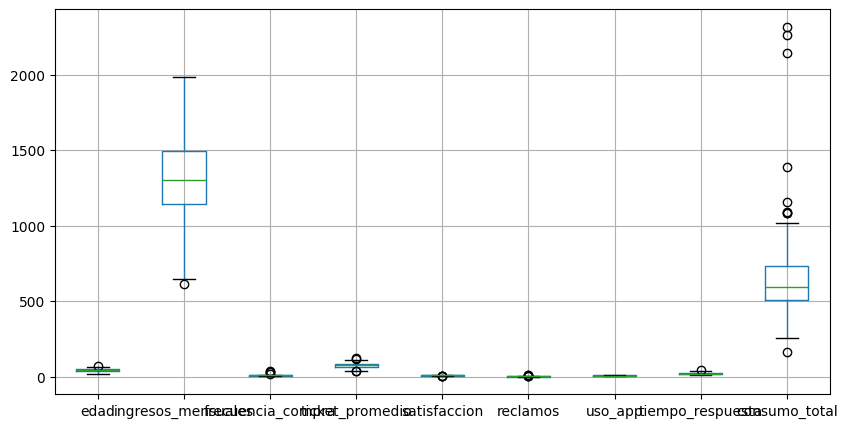

In [6]:
df.boxplot(figsize=(10,5))

consistencia general

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          261 non-null    object 
 1   edad                261 non-null    int64  
 2   ingresos_mensuales  261 non-null    int64  
 3   frecuencia_compra   261 non-null    int64  
 4   ticket_promedio     260 non-null    float64
 5   satisfaccion        260 non-null    float64
 6   reclamos            261 non-null    int64  
 7   uso_app             261 non-null    int64  
 8   tiempo_respuesta    260 non-null    float64
 9   consumo_total       261 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 20.5+ KB
None


In [8]:
print(df.describe())

             edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
count  261.000000          261.000000         261.000000       260.000000   
mean    41.582375         1306.670498           8.785441        75.444577   
std      9.579521          249.936035           3.430623        15.107355   
min     18.000000          616.000000           3.000000        36.070000   
25%     35.000000         1145.000000           7.000000        65.680000   
50%     42.000000         1301.000000           8.000000        77.025000   
75%     48.000000         1491.000000          10.000000        84.962500   
max     68.000000         1987.000000          35.000000       120.320000   

       satisfaccion    reclamos     uso_app  tiempo_respuesta  consumo_total  
count    260.000000  261.000000  261.000000        260.000000     261.000000  
mean       7.624154    1.544061    6.298851         21.158962     636.671954  
std        1.268758    1.560009    1.883828          6.131684     248

-- Calcular Matriz de correlacion

In [9]:
df_numeric = df.select_dtypes(include=['number'])

In [10]:
matriz = df_numeric.corr()
matriz

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.029352,-0.049433,0.174770,-0.161629,0.137255,0.028469,0.130997,0.021224
ingresos_mensuales,0.029352,1.000000,0.194249,0.602224,-0.018640,-0.046700,-0.022801,-0.002620,0.404731
frecuencia_compra,-0.049433,0.194249,1.000000,0.115548,0.160631,-0.123274,0.317643,-0.089462,0.895625
ticket_promedio,0.174770,0.602224,0.115548,1.000000,-0.030465,0.022643,0.017692,-0.001653,0.498709
satisfaccion,-0.161629,-0.018640,0.160631,-0.030465,1.000000,-0.814016,0.007080,-0.635141,0.192574
reclamos,0.137255,-0.046700,-0.123274,0.022643,-0.814016,1.000000,0.125069,0.581399,-0.164746
uso_app,0.028469,-0.022801,0.317643,0.017692,0.007080,0.125069,1.000000,-0.098560,0.301297
tiempo_respuesta,0.130997,-0.002620,-0.089462,-0.001653,-0.635141,0.581399,-0.098560,1.000000,-0.141260
consumo_total,0.021224,0.404731,0.895625,0.498709,0.192574,-0.164746,0.301297,-0.141260,1.000000


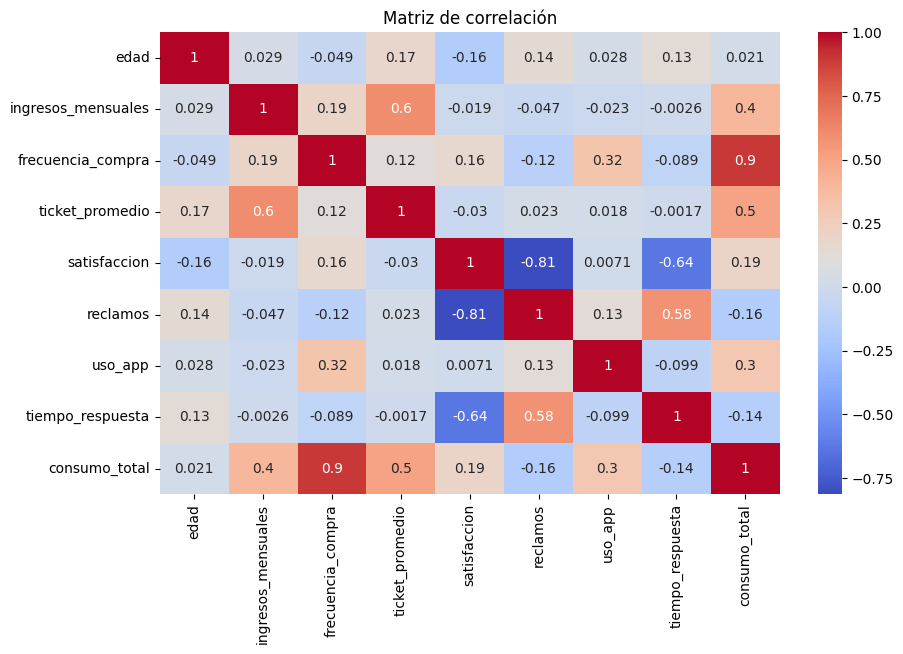

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(matriz, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


Crear un mapa de calor o gráfico de correlación.

In [12]:
import matplotlib.pyplot as plt


In [13]:
correlacion = df.corr(numeric_only=True)


Crear mapa de calor

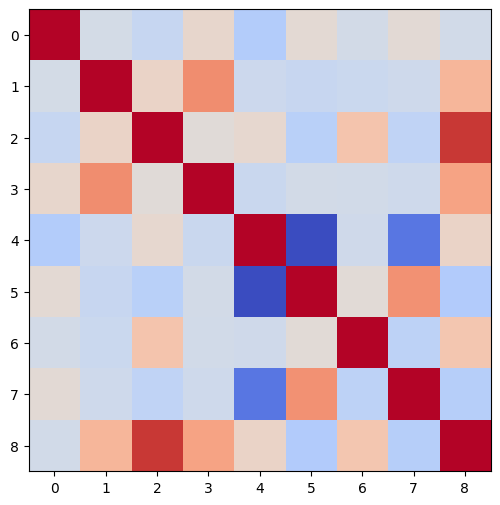

In [15]:
plt.figure(figsize=(8,6))

plt.imshow(correlacion, cmap='coolwarm', interpolation='nearest')


**Correlaciones positivas más importantes**

1. frecuencia_compra y consumo_total (0.90)
Existe una correlación positiva muy fuerte, lo que indica que mientras mayor sea la frecuencia de compra de los clientes, mayor será el consumo total generado.

2. ingresos_mensuales y ticket_promedio (0.60)
Los clientes con mayores ingresos mensuales tienden a realizar compras de mayor valor promedio.

3. ticket_promedio y consumo_total (0.50)
Un aumento en el ticket promedio está relacionado con un mayor consumo total de los clientes.

4. ingresos_mensuales y consumo_total (0.40)
Los clientes con mayores ingresos generalmente generan un mayor nivel de consumo.

**Identificar las correlaciones negativas más importantes.**

1. satisfaccion y reclamos (-0.81)
Existe una correlación negativa muy fuerte, lo que significa que a mayor cantidad de reclamos, menor es el nivel de satisfacción de los clientes.

2. satisfaccion y tiempo_respuesta (-0.64)
Cuando el tiempo de respuesta aumenta, la satisfacción de los clientes disminuye considerablemente.

3. reclamos y consumo_total (-0.16)
Un mayor número de reclamos puede estar relacionado con una ligera disminución en el consumo total.

4. edad y satisfaccion (-0.16)
Se observa una leve tendencia donde algunos clientes de mayor edad presentan menores niveles de satisfacción.

**Explicar al menos 4 relaciones encontradas entre variables.**

1. Frecuencia de compra y consumo total
Se encontró una relación positiva muy fuerte entre la frecuencia de compra y el consumo total. Esto indica que los clientes que compran con mayor frecuencia tienden a generar un mayor volumen de consumo para la empresa.

2. Ingresos mensuales y ticket promedio
Los clientes con mayores ingresos mensuales suelen realizar compras de mayor valor promedio. Esto sugiere que el nivel económico influye directamente en la capacidad de gasto de los clientes.

3. Satisfacción y reclamos
Existe una relación negativa fuerte entre satisfacción y reclamos. A medida que aumentan los reclamos de los clientes, los niveles de satisfacción disminuyen considerablemente.

4. Satisfacción y tiempo de respuesta
Se identificó que tiempos de respuesta más altos están asociados con menores niveles de satisfacción. Esto demuestra la importancia de brindar atención rápida y eficiente a los clientes.

conclusion

Las relaciones encontradas permiten a la empresa comprender mejor el comportamiento de sus clientes y tomar decisiones estratégicas basadas en datos. Por ejemplo, identificar que la frecuencia de compra está relacionada con el consumo total ayuda a diseñar estrategias de fidelización y promociones para incentivar compras recurrentes. Además, la relación negativa entre satisfacción, reclamos y tiempo de respuesta demuestra la importancia de mejorar la atención al cliente para aumentar la satisfacción y mantener clientes más leales. En conjunto, estos análisis permiten optimizar campañas de marketing, mejorar el servicio y aumentar la rentabilidad de la empresa.